# Week 4: Convolutional Neural Networks

In this lab, we will learn to build a CNN model to an image task and evaluate the performence of the model.

**Submission is required for this lab. It worths 3 points. Please run all the cells before you submit.**

---

In [1]:
import torch                             # Core PyTorch library — tensors, autograd
import torch.nn as nn                    # Neural network modules (layers, activations, losses)
import torch.optim as optim              # Optimisers: Adam, SGD, etc.
import torch.nn.functional as F          # Functional API: relu, softmax, etc.

from torch.utils.data import DataLoader  # Wraps datasets and loads them in mini-batches
import torchvision                        # PyTorch's computer vision toolkit
import torchvision.transforms as transforms  # Pre-processing for images

import matplotlib.pyplot as plt           # Plotting library for charts and images
import seaborn as sns                     # Statistical visualisation (used for heatmaps)
import numpy as np                        # Numerical computing
from sklearn.metrics import confusion_matrix  # For computing the confusion matrix

[HAMI-core Msg(2294:139815571217728:libvgpu.c:839)]: Initializing.....


In [2]:
# GPU can significantly speed up training and inference for deep learning models. 
# To use GPU in google colab, go to "Runtime" → "Change runtime type" → select "GPU" as the hardware accelerator. 
# The below function checks for the availability of CUDA (NVIDIA GPUs) and Apple's MPS (Metal Performance Shaders) for Mac, and returns the appropriate device. If neither is available, it defaults to CPU.
# To use GPU in your code, simply call `device = get_device()` and then move your model and tensors to that device using `.to(device)`.
def get_device():
    """Select the best available accelerator, otherwise fall back to CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


device = get_device()
print(f"Using device: {device}")

Using device: cuda


[HAMI-core Msg(2294:139815571217728:libvgpu.c:855)]: Initialized


## Section 1: Dataset

An image is consist of many pixels. 
A **grayscale image** represents each pixel as a single value from 0 (black) to 255 (white).
A **color image** represents each pixel using three values: red(R), green(G), and blue(B).

In PyTorch, images are represented as tensors with shape $(C, H, W)$:
- $C$ = number of **Channels** (1 for grayscale, 3 for RGB colour)
- $H$ = image **Height** in pixels
- $W$ = image **Width** in pixels




Fashion-MNIST is a dataset of **70,000 grayscale images** of clothing items ($28 \times 28$ pixels), split into 60,000 training and 10,000 test images.

Fashion-MNIST has 10 Classes:

| Label | Class | Label | Class |
|---|---|---|---|
| 0 | T-shirt/top | 5 | Sandal |
| 1 | Trouser | 6 | Shirt |
| 2 | Pullover | 7 | Sneaker |
| 3 | Dress | 8 | Bag |
| 4 | Coat | 9 | Ankle boot |

Items like *Shirt*, *Coat*, and *Pullover* look visually similar in tensor space. The CNN must learn *fine-grained* spatial features to tell them apart.

Let's first load the training dataset and test dataset.

In [3]:
# Class names — we will use this list throughout the notebook
CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal',      'Shirt',   'Sneaker',  'Bag',   'Ankle boot']

#   ToTensor(): converts image (H×W, 0–255) to tensor (1, H, W, range 0.0–1.0)
transform = transforms.Compose([
    transforms.ToTensor()
])

# Download (first run only) and load the training set (60 000 images)
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True,  download=True, transform=transform
)

# Download (first run only) and load the test set (10 000 images)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

print(f"Training samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")
print(f"Single image shape: {train_dataset[0][0].shape}")   # Should be torch.Size([1, 28, 28])

Training samples : 60000
Test samples     : 10000
Single image shape: torch.Size([1, 28, 28])


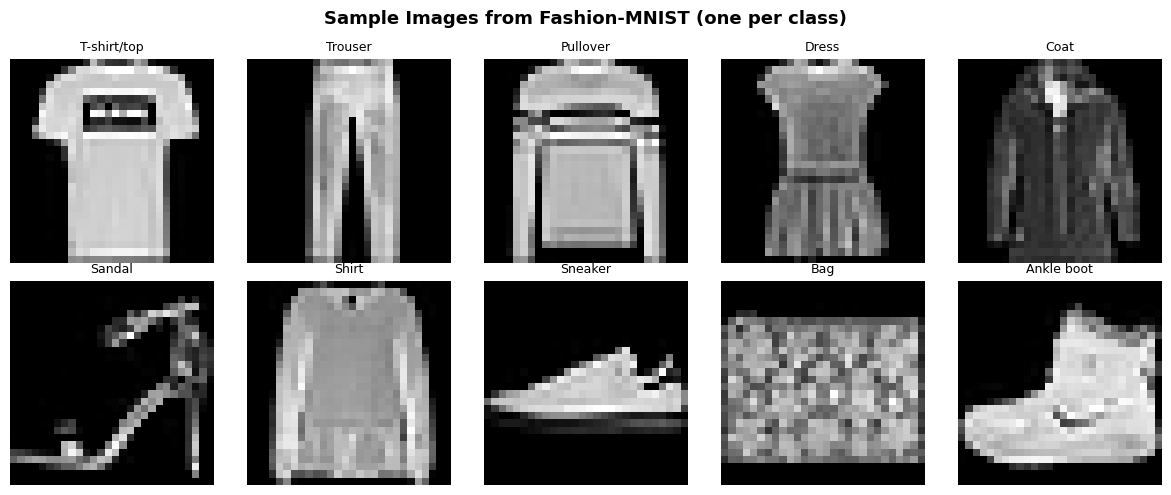

In [4]:
# The following code visualises sample images from Fashion-MNIST

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Sample Images from Fashion-MNIST (one per class)", fontsize=13, fontweight='bold')

# Find one sample from each of the 10 classes
shown = {}
for img, lbl in train_dataset:
    if lbl not in shown:
        shown[lbl] = img
    if len(shown) == 10:
        break

for i, ax in enumerate(axes.flat):
    img = shown[i]                              # tensor shape (1, 28, 28)
    ax.imshow(img.squeeze(), cmap='gray')        # squeeze() removes channel dim → (28, 28)
    ax.set_title(CLASS_NAMES[i], fontsize=9)
    ax.axis('off')                               # hide axis ticks

plt.tight_layout()
plt.show()

In [5]:
# TODO 1: Create DataLoaders for batch processing, set shuffling for training data and no shuffling for test data, why? 

BATCH_SIZE = 64  # Number of images processed per gradient update step

train_loader = DataLoader(train_dataset, batch_size=64, shuffle= True)

test_loader = DataLoader(test_dataset, batch_size=64, shuffle= False)


## Section 2: Implement the Convolutional Layer

### Convolution

In PyTorch, we use `nn.Conv2d` to apply a 2D convolution operation over an input image
```python
nn.Conv2d(in_channels, out_channels, kernel_size, padding=1)
```

| Parameter | Meaning |
|---|---|
| `in_channels` | Channels in the input tensor (1 for grayscale, 3 for RGB) |
| `out_channels` | Number of filters = number of output channels |
| `kernel_size` | Spatial size of the filter (e.g., `3` = a $3 \times 3$ filter) |
| `padding=1` | Adds a border of zeros so the output has the **same** H and W as input |

**Padding and Spatial Size:**

Without padding, a $3 \times 3$ kernel reduces a $28 \times 28$ input to $26 \times 26$.  
With `padding=1`, it stays $28 \times 28$:

$$H_{\text{out}} = H_{\text{in}} - K + 1 + 2P \quad \Rightarrow \quad 28 - 3 + 1 + 2(1) = 28 \checkmark$$


### Pooling

After a convolution, a feature map might be $(16, 28, 28) = 12{,}544$ values. Without reduction, the next layer processes all of them — and the one after that, and so on. Computation becomes expensive fast.

**Max Pooling** compresses the spatial dimensions by keeping only the most *informative* value in each local window:

$$\begin{bmatrix} 1 & 3 \\ 2 & 5 \end{bmatrix} \;\xrightarrow{\text{MaxPool}}\; 5$$

For a $2 \times 2$ window with stride 2:

$$\text{Input: }(C, H, W) \;\xrightarrow{\text{MaxPool2d(2,2)}}\; \left(C,\; \frac{H}{2},\; \frac{W}{2}\right)$$

In PyTorch, we use `nn.MaxPool2d` to perform downsampling by applying a sliding window over each feature map and taking the maximum value within each window. This reduces the spatial dimensions while keeping the most important features.

```python
nn.MaxPool2d(kernel_size, stride=None, padding=0)
```
| Parameter | Meaning |
|---|---|
| `kernel_size` | Size of the pooling window (e.g., `2` = a $2 \times 2$ window) |
| `stride` | Step size of the window (default is equal to `kernel_size`) |
| `padding` | Adds zero-padding around the input before pooling |

### Flatten
In PyTorch, we use `nn.Flatten` to reshape a multi-dimensional tensor into a 1D vector per sample, typically before passing it into fully connected layers.

```python
nn.Flatten(start_dim=1)
```
| Parameter | Meaning |
|---|---|
| `start_dim` | First dimension to flatten (default is 1, keeping batch dimension unchanged) |


In [6]:
# TODO 2: for a dummy input image, apply a convolutional layer, a pooling layer, and flatten the output. Print the shape after each step to see how it changes.
# Demo: How CNN is applied and how Tensor shapes are changed through each layer
dummy_input = torch.zeros(1, 1, 28, 28)   # (batch=1, channels=1, H=28, W=28 - represents a blank 28×28 grayscale image.)


demo_conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1) #Convolutional Layer 
demo_pool  = nn.MaxPool2d(kernel_size=2)
flat = nn.Flatten(start_dim=1)

after_conv1 = demo_conv1(dummy_input)
after_pool1 = demo_pool(after_conv1)
flat= flat(after_pool1)

print(f"Input shape              : {dummy_input.shape}")
print(f"After Conv2d(1→16)  : {after_conv1.shape}")   # (1, 16, 28, 28)
print(f"After MaxPool2d(2,2)     : {after_pool1.shape}")    # (1, 16, 14, 14)
print(f"After Flatten            : {flat.shape}")           # (1, 3136) note: 1*16*14*14 = 3136

Input shape              : torch.Size([1, 1, 28, 28])
After Conv2d(1→16)  : torch.Size([1, 16, 28, 28])
After MaxPool2d(2,2)     : torch.Size([1, 16, 14, 14])
After Flatten            : torch.Size([1, 3136])


## Section 3: Building the CNN Architecture

We will build a CNN use ReLU as the activation function and Cross-Entropy Loss as the loss function. 


In [7]:
# TODO 3: Define the FashionCNN class with the architecture described in the docstring. Fill in the TODOs for conv2 and fc1 layers, and implement the forward pass.
class FashionCNN(nn.Module):
    """
    A Convolutional Neural Network for Fashion-MNIST (10-class) classification.

    Architecture:
        Conv1(1→16, 3×3, pad=1) → ReLU → MaxPool(2×2)
        Conv2(16→32, 3×3, pad=1) → ReLU → MaxPool(2×2)
        Flatten  →  FC1(1568→128) → ReLU  →  FC2(128→10)
    """

    def __init__(self):
        super(FashionCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.activation = nn.ReLU()
        self.pool= nn.MaxPool2d(2) # define the pool here 
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear (1568, 128)
        self.fc2 = nn.Linear(128, 10) 
        
    def forward(self, x):
        """
        Defines the forward pass: how data flows through the network.
        x shape on entry: (batch_size, 1, 28, 28)
        """
        # Conv1 → ReLU → Pool (1st layer)
        x = self.conv1(x)
        x = self.activation(x)
        x = self.pool(x)

        # Conv2 → ReLU → Pool (2nd layer) 
        x = self.conv2(x)
        x = self.activation(x) 
        x = self.pool(x)

        # Flatten
        x = torch.flatten(x, 1) # # or nn.Flatten() 

        # FC1 → ReLU → FC2 
        x = self.fc1 (x)
        x = self.activation(x)
        x = self.fc2(x)
        
        return x


# Instantiate the model and print its architecture. Then, pass a dummy input through the model to verify the output shape is correct (should be [batch_size, 10]).
model = FashionCNN().to(device)
print(f"Using device: {device}")
print(model)
dummy = torch.zeros(2, 1, 28, 28, device=device)
out   = model(dummy)
print(f"Output shape: {out.shape}")   # Expected: torch.Size([2, 10])

Using device: cuda
FashionCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (activation): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Output shape: torch.Size([2, 10])


The outputs are 10 numbers called **logits**. These are the raw, unnormalised scores, and the class with the **highest logit** is the model's prediction.  


## Section 4: The Training Loop

Like other neural networks, training a CNN proceeds in four steps.

| Step | Action | PyTorch Call |
|---|---|---|
| 1. **Forward pass** | Feed a batch through the model; get predicted scores | `outputs = model(images)` |
| 2. **Compute loss** | Measure how wrong the predictions are | `loss = criterion(outputs, labels)` |
| 3. **Backward pass** | Compute gradients (which direction to nudge each weight) | `loss.backward()` |
| 4. **Update weights** | Move each weight slightly in the direction that reduces loss | `optimizer.step()` |


We will use the Adam optimizer with a learning rate of 0.001.

In [8]:
# TODO 4: Implement the training loop for the FashionCNN model. return a history dictionary containing train/val loss and accuracy over epochs.

def train_model(model, train_loader, test_loader, epochs=10, lr=0.001, device=None):
    """
    Train and validate a CNN model.
    Returns: history dict containing train/val loss and accuracy over epochs.
    """
    if device is None:
        device = get_device()

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):

        # -------------------- TRAINING PHASE --------------------
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)

        # -------------------- VALIDATION PHASE ------------------
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                correct_val += (preds == labels).sum().item()
                total_val += labels.size(0)

        # -------------------- METRICS ---------------------------
        avg_train_loss = running_loss / len(train_loader)
        avg_val_loss = val_loss / len(test_loader)
        train_acc = 100 * correct_train / total_train
        val_acc = 100 * correct_val / total_val

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch [{epoch+1:2d}/{epochs}] | "
              f"Train Loss: {avg_train_loss:.4f}  Train Acc: {train_acc:.1f}% | "
              f"Val Loss: {avg_val_loss:.4f}  Val Acc: {val_acc:.1f}%")

    return history


# ---- Run training after completing all TODOs ----
print("Instantiating FashionCNN...")
cnn_model = FashionCNN().to(device)

print(f"\nTraining on device: {device}")
print("Starting training...")
history = train_model(cnn_model, train_loader, test_loader, epochs=10, lr=0.001, device=device)

Instantiating FashionCNN...

Training on device: cuda
Starting training...
Epoch [ 1/10] | Train Loss: 0.5092  Train Acc: 81.7% | Val Loss: 0.3722  Val Acc: 86.7%
Epoch [ 2/10] | Train Loss: 0.3293  Train Acc: 88.1% | Val Loss: 0.3415  Val Acc: 87.7%
Epoch [ 3/10] | Train Loss: 0.2820  Train Acc: 89.7% | Val Loss: 0.2945  Val Acc: 89.3%
Epoch [ 4/10] | Train Loss: 0.2517  Train Acc: 90.8% | Val Loss: 0.2829  Val Acc: 89.5%
Epoch [ 5/10] | Train Loss: 0.2333  Train Acc: 91.5% | Val Loss: 0.2620  Val Acc: 90.5%
Epoch [ 6/10] | Train Loss: 0.2122  Train Acc: 92.2% | Val Loss: 0.2542  Val Acc: 90.6%
Epoch [ 7/10] | Train Loss: 0.1957  Train Acc: 92.7% | Val Loss: 0.2424  Val Acc: 91.5%
Epoch [ 8/10] | Train Loss: 0.1823  Train Acc: 93.2% | Val Loss: 0.2449  Val Acc: 91.4%
Epoch [ 9/10] | Train Loss: 0.1662  Train Acc: 93.9% | Val Loss: 0.2642  Val Acc: 90.6%
Epoch [10/10] | Train Loss: 0.1533  Train Acc: 94.3% | Val Loss: 0.2484  Val Acc: 91.4%


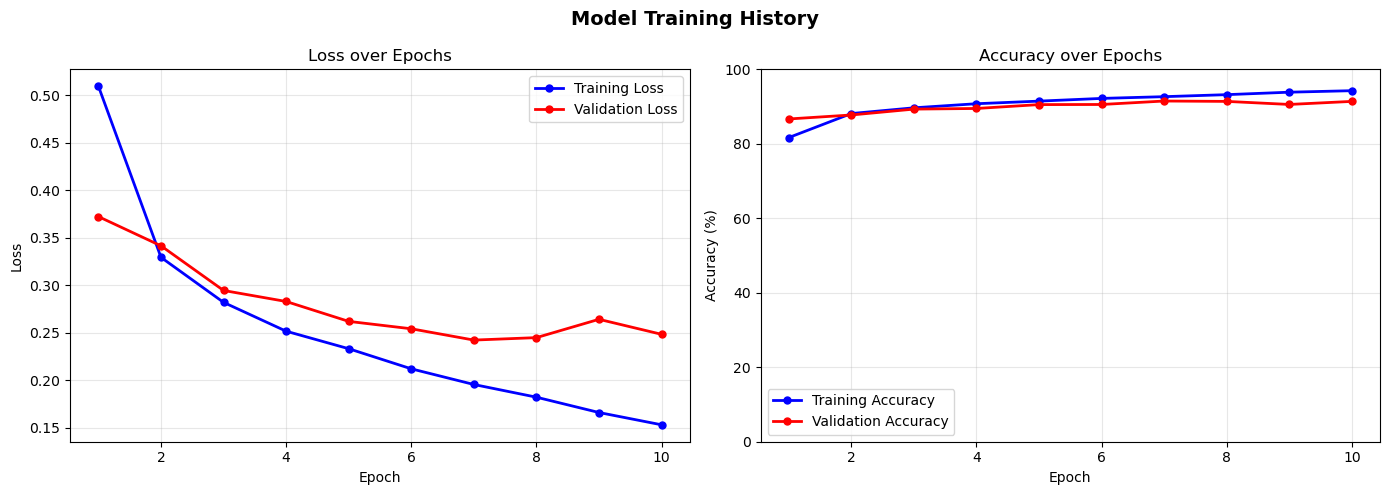

Final Train Accuracy      : 94.3%
Final Validation Accuracy : 91.4%


In [9]:
# Visualise: Training and Validation Loss & Accuracy Curves

epochs_range = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Training History", fontsize=14, fontweight='bold')

# ── Loss plot ──
ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Training Loss',   linewidth=2, markersize=5)
ax1.plot(epochs_range, history['val_loss'],   'r-o', label='Validation Loss', linewidth=2, markersize=5)
ax1.set_title("Loss over Epochs", fontsize=12)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── Accuracy plot ──
ax2.plot(epochs_range, history['train_acc'], 'b-o', label='Training Accuracy',   linewidth=2, markersize=5)
ax2.plot(epochs_range, history['val_acc'],   'r-o', label='Validation Accuracy', linewidth=2, markersize=5)
ax2.set_title("Accuracy over Epochs", fontsize=12)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 100])

plt.tight_layout()
plt.show()

print(f"Final Train Accuracy      : {history['train_acc'][-1]:.1f}%")
print(f"Final Validation Accuracy : {history['val_acc'][-1]:.1f}%")

# A large gap between these two numbers is a sign of overfitting!

## Section 5: Model Evaluation: The Confusion Matrix

A model with 88% accuracy might be failing consistently on specific classes. For example, it might classify "Ankle boot" perfectly but confuse "Coat" and "Pullover" almost every time.

The **Confusion Matrix** gives a complete picture:

| | Predicted: Coat | Predicted: Pullover |
|---|---|---|
| **True: Coat** | 850 (correct) | 150 (confused as Pullover) |
| **True: Pullover** | 200 (confused as Coat) | 800 (correct) |


In [10]:
# TODO 5: Implement the get_all_predictions function to run the model over the entire test set and collect predicted vs. true labels. This will be used for computing the confusion matrix and visualising misclassified examples.
def get_all_predictions(model, loader, device=None):
    """Run the model over an entire DataLoader and collect predictions vs. ground truth."""
    if device is None:
        device = next(model.parameters()).device
    
    all_preds  = []
    all_labels = []

    model.eval()
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1)
            
            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return np.array(all_labels), np.array(all_preds)


# Collect predictions from the trained model
true_labels, pred_labels = get_all_predictions(cnn_model, test_loader, device=device)


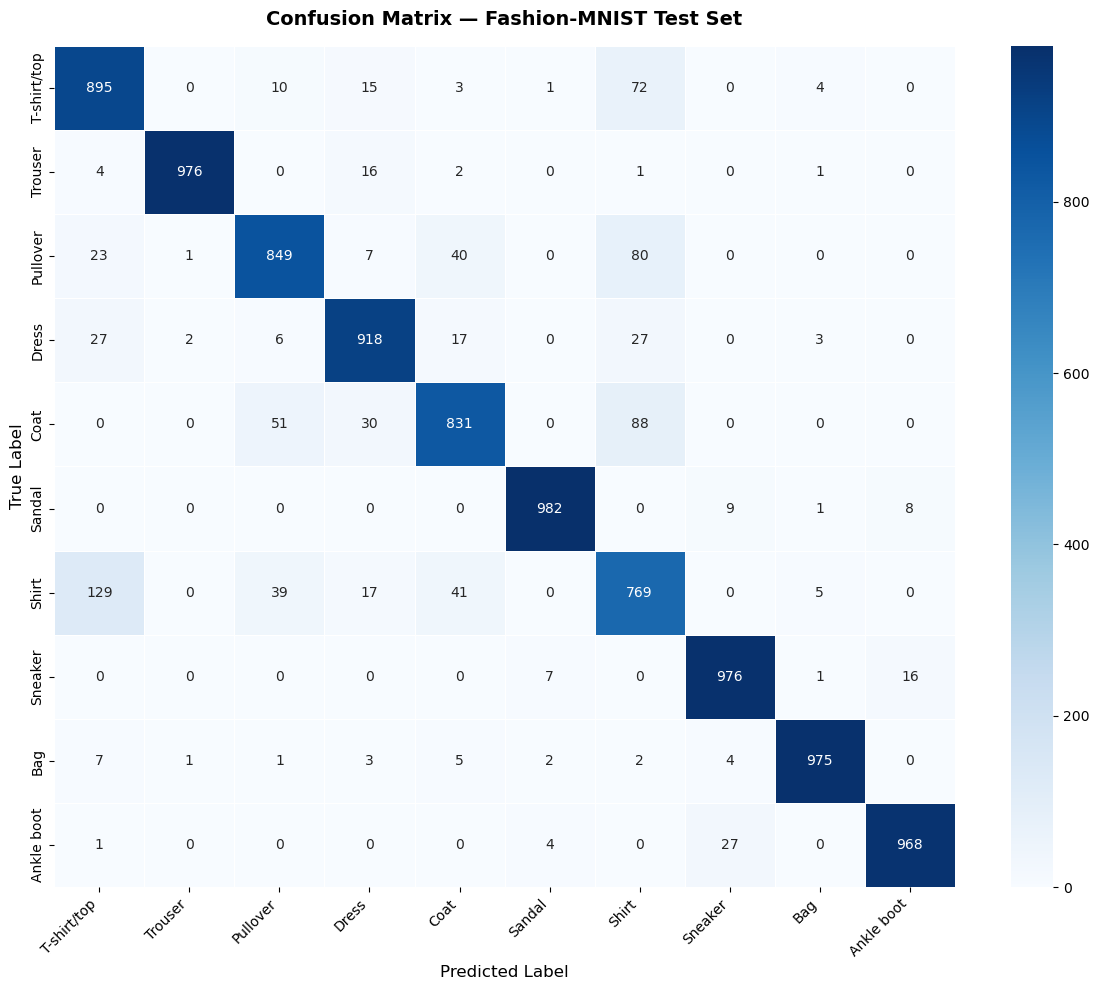


Per-Class Accuracy on Test Set:
--------------------------------------
  T-shirt/top     :  89.5%
  Trouser         :  97.6%
  Pullover        :  84.9%
  Dress           :  91.8%
  Coat            :  83.1%
  Sandal          :  98.2%
  Shirt           :  76.9%
  Sneaker         :  97.6%
  Bag             :  97.5%
  Ankle boot      :  96.8%


In [11]:
# This cell implements Confusion Matrix to visualise Per-Class performance

# Build the 10×10 confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

# Plot as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,            # show count in each cell
    fmt='d',               # integer format
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.4
)
plt.title("Confusion Matrix — Fashion-MNIST Test Set", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label",      fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Per-class accuracy summary
print("\nPer-Class Accuracy on Test Set:")
print("-" * 38)
for i, name in enumerate(CLASS_NAMES):
    acc = 100 * cm[i, i] / cm[i].sum()
    print(f"  {name:<15} : {acc:5.1f}%")

**Reflection:**
1. Why is padding=1 used with a 3×3 kernel? What would happen to the final flattened size if padding were removed from both conv layers?
2. Max pooling discards 75% of values. Yet the model still classifies correctly most of the time. What does this tell you about where useful information lives in a feature map? Is it uniformly distributed, or concentrated in peaks?
3. As the image moves deeper into the network, its height and width get smaller, but the number of channels increases (from 1 to 16, then 32). Why do we need more channels in the deeper layers? What are they looking for?
4. Look at your final loss curves. If the training loss keeps going down to zero, but the validation loss stops dropping and starts going up, what is happening? Is the model learning or just memorizing?
5. If the confusion matrix shows that the model often mistakes a "Coat" for a "Pullover," is this a failure of the mathematics, or is it a reflection of the data itself? How would you explain this mistake to a non-technical person?

**Optional Tasks:**
- Learning rate schedule: try different learning rate schedulers, investigate the loss curve and describe what happens.
- Add a Dropout Layer: insert nn.Dropout(p=0.25) before your fully connected layer to observe if it narrows the gap between training accuracy and validation accuracy (reducing overfitting).
- Upload a raw smartphone picture of your own t-shirt, resize it to $28 \times 28$ pixels, grayscale it, and see if your trained model can guess what it is.